# Chunking


## Loading

In [1]:
import sys
#print(sys.executable)
#!{sys.executable} -m pip install langchain_experimental
#!pip install jq
import os
#had problems with directory
print(os.getcwd())
from pathlib import Path
import json
from langchain_community.document_loaders import JSONLoader

PROJECT_ROOT = Path("C:/Users/filip/Desktop/Thesis/project")
DATA_DIR = PROJECT_ROOT / "data"
TEST_JSON = DATA_DIR / "test" / "algae-1998-13-1-1.json"
print(os.getcwd())

c:\Users\filip\Desktop\Thesis\project\notebooks
c:\Users\filip\Desktop\Thesis\project\notebooks


In [2]:
loader = JSONLoader(
    file_path=TEST_JSON,
    jq_schema=".text",
    text_content=False,
)
docs = loader.load()
print(docs[0].page_content)


Algae (The Korean Journal of Phycology) Volume 13(1): 1-11, 1998

Marine Flora of Oeyondo Islands on the Yellow Sea, Korea: I. Green Algae and Seagrasses

Tae Oh Cho and Sung Min Boo*

Department of Biology, Chungnam National University, Daejon 305-764, Korea

A marine floral survey of benthic green algae and seagrasses was carried out in Oeyondo Islands on the Yellow Sea of Korea from 1992 to 1994. A list of nine genera and eighteen species was compiled: 13 green algae and 5 sea- grasses. Detailed illustrations as well as the keys and short descriptions were given for most of the taxa.

Key Words: green algae, marine flora, Oeyondo, seagrasses, Yellow Sea

INTRODUCTION

A species list of marine benthic algae from Korea have been published by Lee and Kang (1986). This work has made a compilation of the previous accounts studied from all the coasts and a significant contribution for the further understanding of species diverisity and biogeog- raphy of marine algae of Korea. Many of the 

# Semantic chunking
This part is dedicated to testing one of chunking strategies  - semantic chunking. Based on my literature review ad consultations with my supervisor, I believe this to be the best.

In [3]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

## Model loading

In [4]:
from sentence_transformers import SentenceTransformer
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}  # BGE models benefit from normalization
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1188.29it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Embedding
For grouping by semantic meaning

In [5]:
test = embedding_model.embed_query("test")
print(len(test))  # it is 768, because this model embeds in a 768-dimensional vector space

768


In [6]:
chunker = SemanticChunker(
    embeddings=embedding_model,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=95,
)

chunks = chunker.create_documents([docs[0].page_content])
print(f"Got {len(chunks)} chunks")

Got 28 chunks


## Preview

In [7]:
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i} ({len(chunk.page_content)} chars) ---")
    print(chunk.page_content[:1000])
    print()

--- Chunk 0 (5493 chars) ---
Algae (The Korean Journal of Phycology) Volume 13(1): 1-11, 1998

Marine Flora of Oeyondo Islands on the Yellow Sea, Korea: I. Green Algae and Seagrasses

Tae Oh Cho and Sung Min Boo*

Department of Biology, Chungnam National University, Daejon 305-764, Korea

A marine floral survey of benthic green algae and seagrasses was carried out in Oeyondo Islands on the Yellow Sea of Korea from 1992 to 1994. A list of nine genera and eighteen species was compiled: 13 green algae and 5 sea- grasses. Detailed illustrations as well as the keys and short descriptions were given for most of the taxa. Key Words: green algae, marine flora, Oeyondo, seagrasses, Yellow Sea

INTRODUCTION

A species list of marine benthic algae from Korea have been published by Lee and Kang (1986). This work has made a compilation of the previous accounts studied from all the coasts and a significant contribution for the further understanding of species diverisity and biogeog- raphy of marine 

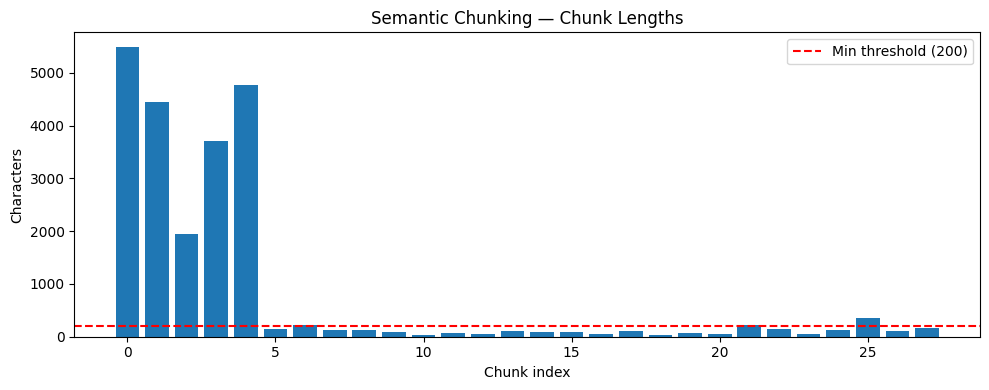

In [8]:
import matplotlib.pyplot as plt

lengths = [len(c.page_content) for c in chunks]

plt.figure(figsize=(10, 4))
plt.bar(range(len(lengths)), lengths)
plt.xlabel("Chunk index")
plt.ylabel("Characters")
plt.title("Semantic Chunking — Chunk Lengths")
plt.axhline(y=200, color="red", linestyle="--", label="Min threshold (200)")
plt.legend()
plt.tight_layout()
plt.show()

## Preprocessing
First I remove the references and acknowledgements, then I remove figure descriptions. 
### Removing references and acknowledgments

In [9]:
#deleting useless references and acknowledgments. Using regex to find them.
import re

def find_references(text: str) -> int:
    """Returns the character index to cut at, or len(text) if not found."""
    
    # Tryies explicit headers first (English and common variants)
    header_pattern = re.compile(
        r'\n\s*(References|Bibliography|Acknowledgements?|감사의\s*글|참고\s*문헌)\s*\n',
        re.IGNORECASE
    )
    match = header_pattern.search(text)
    if match:
        return match.start()
    
    # Fallback: finds where citation-dense lines start
    lines = text.split('\n')
    citation_pattern = re.compile(r'\b(19|20)\d{2}[a-z]?\b')
    #This is a sliding window of 5 lines to search in. If any window has over 4 lines containing a year, it is most likely the list of references.
    window_size = 5
    for i in range(len(lines) - window_size):
        window = lines[i:i + window_size]
        hits = sum(1 for line in window if citation_pattern.search(line))
        if hits >= 4:
            return text.index(lines[i])
    
    return len(text)

In [10]:
#length until start of references
print(find_references(docs[0].page_content))
#length of full paper
print(len((docs[0].page_content)))

#the function didnt work, so i am checking the document
print(docs[0].page_content[-2800:])

20190
23129
hanked for her assistance for preparing illustra- tions.

REFERENCES

Cho T.O. and Boo S.M. 1996. Seasonal changes of marine plants in Oeyondo Islands on the Yellow Sea. Algae 11: 285-293.

Cotton A.D. 1906. Marine algae from Corea. Bull. Misc. Inform. Royal Bot. Garden Kew. 1906: 366-373.

Hoek, C. van den. 1984a. Systematics of the Cladophorales. In: The systematics of the green algae. (Ed.), by D.E.G. Irvine and D.M. John. Acad. Press, New York: 157-178.

Kang J.W. 1966. On the geographical distribution of marine algae in Korea. Bull. Pusan Fish. Coll. 7: 1-125.

Koh C.H. and Oh $.H. 1992. Distribution pattern of — macroal- gae in the eastern Yellow Sea, Korea. Korean J. Phycol. 7: 139-146.

Lee H.B. and Lee I.K. 1981. Flora of benthic marine algae in

Gyeongi Bay, western coast of Korea. Korean J. Bot. 24: 107- 138. Lee I.K. and Boo S.M. 1988. A summer marine algal flora of

Oeyondo Islands. Korean Preser. Nat. Rep. 8: 233-256.

Lee IK. and Kang J.W. 1986. A check list 

In [11]:
#locating REFERENCES header position
idx = docs[0].page_content.find("REFERENCES")
print(repr(docs[0].page_content[idx-50:idx+50]))

'or her assistance for preparing illustra- tions.\n\nREFERENCES\n\nCho T.O. and Boo S.M. 1996. Seasonal c'


In [12]:
text = docs[0].page_content
cutpoint = find_references(text)
body = text[:cutpoint]
print(body[-1000:])

ee veins, that needs a further study on the Korean plants.

Zostera caulescens Miki, Figs 42-52

Plants 165 cm‘high, submerged. Leaves obtuse, seven in vein, 0.8 + 0.1 cm. Stems cylindrical, 0.5 + 0.1 cm broad, with internodes of 22.0 + 8.6 cm. Seeds with smooth testa, 9.9 + 1.3 cm long, 0.9 + 0.1 cm broad. Plants on muddy area in the sublittoral and reproductive in summer.

Note: The Korean plants are variable in the number of vein. We found plants with 5 or 7 veins. This needs a fur- ther study how the number of veins can differ in a single location.

Zostera marina Linnaeus, Figs 53-59

Plants 27 cm tall, submerged. Leaves mucronate, seven in vein, 0.5-0.1 cm broad. Stem 0.3 + 0.1 cm broad, with internodes of 7.6 + 2.2 cm. Seeds 5.8-1.2 cm long, 0.5 + 0.1 cm broad, with rough testa. Plants on muddy area in the sublittoral and reproductive in summer.

Note: The plants with seven veins are easily confused with Z. caulacanthus, but differ from the latter in having rough testa of seeds.

### Removing Figure descriptions

In [13]:
fig_pattern = re.compile(
    r'((?:Figs?|Figures?)\s*\.?\s*\d+(?:[-–—]\d+)?\..*?)(?=\n\n|\Z)',
    re.DOTALL
)

In [14]:
matches = fig_pattern.findall(docs[0].page_content)
for m in matches:
    print(repr(m[:100]))
    print()

'Fig. 1. Map of Oeyondo Islands (arrow) in the Yellow Sea of Korea. Flora was studied in the southern'

'Figs 2-11. Members of Ulotrichaceae and Monostromataceae. 2-3. Ulothrix flacca. 2. Upper part of fil'

'Figs 12-21. Members of Monostromataceae and Cladophoraceae. 12-13. Enteromorpha linza. 12. Transvers'

'Figs 22-31. Members of Codiaceae and Zosteraceae. 22-23. Codium adhaerens. 22. Utricle cluster with '

'Figs 32-41. Member of Zosteraceae. 32-38. Phyllospadix iwatensis. 32. Apex with five veins (Ve) in t'

'Figs 42-52. Zostera caulescens. 42. Apex with nine veins (Ve) in the upper part of leaf. 43. Surface'

'Figs 53-59. Zostera marina. 53. Apex with seven veins (Ve). 54. Surface of leaf. 55. Surface of seed'



In [15]:
cleaned_text = fig_pattern.sub('', text)
cleaned_text = re.sub(r'\n{3,}', '\n\n', cleaned_text)

Now that I got rid of figures, I want to extract the necessary information for citations so I can save them in a json.
I want to extract:
* title: one of the first things written in the coument
* author: right under title
* journal: all my documents are from the journal *Algae*
* year: also in the file name
* volume/issue: same


In [16]:
#how I extract year
#example = "algae-2003-18-4-361"
#year = example[6:10]
#print(year)

In [17]:
#how I extract authors
import ollama

response = ollama.chat(
    model="gemma3:1b",#mistral took 58 seconds, gemma 3:4b 4.6 secs
    messages=[{
        "role": "user",
        "content": f"""Extract the title and authors from this paper header.
Return ONLY valid JSON: {{"title": "...", "authors": ["..."]}}

Text: {docs[0].page_content[:500]}"""
    }]
)

print(response["message"]["content"])

```json
{"title": "Marine Flora of Oeyondo Islands on the Yellow Sea of Korea", "authors": ["Tae Oh Cho", "Sung Min Boo"]}
```



In [28]:
def preprocess_document(json_path: Path) -> dict:
    with open(json_path, "r", encoding="utf-8") as f:
        doc = json.load(f)
    
    text = doc["text"]
    filename = doc["filename"]
    
    # Extracts metadata via gemma. 1b is fast and works well enough for this job
    response = ollama.chat(
        model="gemma3:1b",
        messages=[{
            "role": "user",
            "content": f"""Extract the title and authors from this paper header.
Return ONLY valid JSON: {{"title": "...", "authors": ["..."]}}

Text: {text[:500]}"""
        }]
    )
    raw = response["message"]["content"]
    raw = raw.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    try:
        metadata = json.loads(raw)
    except json.JSONDecodeError:
        metadata = {"title": None, "authors": None}
    
    # summary of document
    summary_response = ollama.chat(
        model="granite3.2:2b",
        messages=[{
            "role": "user",
            "content": f"""You are a marine biology research librarian cataloguing scientific papers.
Summarize what this paper covers in 2-3 sentences. Focus on:
- Which species, organisms, or biological processes are discussed
- Key findings or data reported
- The geographic or ecological context

Be specific with species names and factual claims. This summary will be used
to match the paper to future research queries. Do not include any questions, headers, or bullet points. Return only the summary sentences.

Text: {text[:3000]}"""
        }]
    )
    summary = summary_response["message"]["content"]
    
    # Strip figure captions
    text = fig_pattern.sub('', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    # Strip references and acknowledgements
    cutpoint = find_references(text)
    text = text[:cutpoint]
    
    processed = {
        "filename": filename,
        "title": metadata.get("title"),
        "authors": metadata.get("authors"),
        "year": filename.split("-")[1],
        "summary": summary,
        "text": text.strip()
    }
    
    # Save — TODO: change to DATA_DIR / "processed" for full corpus run
    output_path = PROJECT_ROOT / "outputs" / "test_chunks" / f"{Path(filename).stem}.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(processed, f, ensure_ascii=False, indent=2)
    
    return processed

In [29]:
# TODO: change to DATA_DIR / "processed" for full corpus run
preprocess_document(TEST_JSON)

{'filename': 'algae-1998-13-1-1.pdf',
 'title': 'Marine Flora of Oeyondo Islands on the Yellow Sea of Korea',
 'authors': ['Tae Oh Cho', 'Sung Min Boo'],
 'year': '1998',
 'summary': 'This paper, "Marine Flora of Oeyondo Islands on the Yellow Sea, Korea: I. Green Algae and Seagrasses" from The Korean Journal of Phycology (Volume 13, Issue 1, 1998), focuses on a detailed survey of benthic marine green algae and seagrasses in the Oeyondo Islands, situated 50 km from the Korean mainland in the Yellow Sea. The research, conducted from 1992 to 1994, yielded a list of nine genera and eighteen species, including thirteen green algae and five seagrasses. The authors, Tae Oh Cho and Sung Min Boo, provided comprehensive illustrations, keys, and descriptions for each taxon. The study aimed to enhance the understanding of marine flora in isolated islands, contributing to the knowledge of species diversity and biogeography in Korean marine algae. The research methodology involved collecting samples

# Recursive splitting

In [44]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [45]:
with open(PROJECT_ROOT / "outputs" / "test_chunks" / "algae-1998-13-1-1.json", "r", encoding="utf-8") as f:
    doc = json.load(f)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0,
)

naive_chunks = text_splitter.create_documents([doc["text"]])
print(f"Got {len(naive_chunks)} chunks")

for chunk in naive_chunks[10:15]:
    print(chunk.page_content + "\n")

Got 19 chunks
Branches di- to trichotomous and secund. Upper branch- es straight and simple. Cells 315.8 + 77.9 um long, 92.9 + 6.9 um broad. Apical cells acute, 126 + 22.3 um long, 30.0 + 3.5 um broad. Plants epilithic in the sublittoral in sum- mer. Cladophora opaca Sakai, Figs 20-21

Plants dense, yellowish green, 11 cm high. Branches dichotomous to trichotomous, alternative. Upper

Cho & Boo: Marine Green Flora of Oeyondo Islands 5

branches straight to curved, with secund branchlets. Cells 426.8 + 68.0 um long, 66.0 + 7.4 ym broad. Apical cells acute, 132.8 + 18.9 um long, 32.34 + 1.9 um_ broad. Plants epilithic in the littoral in summer.

Order Codiales Family Bryopsidaceae Bryopsis Lamouroux, 1809 The genus Bryopsis is typified as B. pennata Lamouroux. They are distributed on the temperate to the tropical coasts. Key to the species 1. Plant pinnate form with simple filaments bee e te eeeeaeeeeeeeeesueeeeeeaeeaauneceeane enna Bryopsis maxima 1. Plant pinnate form with bilateral b

In [46]:
output_dir = PROJECT_ROOT / "outputs" / "test_chunks" / "recursive_1000"
output_dir.mkdir(parents=True, exist_ok=True)

chunked = {
    "filename": doc["filename"],
    "title": doc.get("title"),
    "authors": doc.get("authors"),
    "year": doc.get("year"),
    "strategy": "recursive_character",
    "chunk_size": 1000,
    "chunk_overlap": 0,
    "num_chunks": len(naive_chunks),
    "chunks": [
        {"chunk_id": i, "text": c.page_content, "char_length": len(c.page_content)}
        for i, c in enumerate(naive_chunks)
    ]
}

with open(output_dir / f"{Path(doc['filename']).stem}.json", "w", encoding="utf-8") as f:
    json.dump(chunked, f, ensure_ascii=False, indent=2)

In [47]:
print(json.dumps(chunked, indent=2, ensure_ascii=False)[:10000])

{
  "filename": "algae-1998-13-1-1.pdf",
  "title": "Marine Flora of Oeyondo Islands on the Yellow Sea of Korea",
  "authors": [
    "Tae Oh Cho",
    "Sung Min Boo"
  ],
  "year": "1998",
  "strategy": "recursive_character",
  "chunk_size": 1000,
  "chunk_overlap": 0,
  "num_chunks": 19,
  "chunks": [
    {
      "chunk_id": 0,
      "text": "Algae (The Korean Journal of Phycology) Volume 13(1): 1-11, 1998\n\nMarine Flora of Oeyondo Islands on the Yellow Sea, Korea: I. Green Algae and Seagrasses\n\nTae Oh Cho and Sung Min Boo*\n\nDepartment of Biology, Chungnam National University, Daejon 305-764, Korea\n\nA marine floral survey of benthic green algae and seagrasses was carried out in Oeyondo Islands on the Yellow Sea of Korea from 1992 to 1994. A list of nine genera and eighteen species was compiled: 13 green algae and 5 sea- grasses. Detailed illustrations as well as the keys and short descriptions were given for most of the taxa.\n\nKey Words: green algae, marine flora, Oeyondo, se

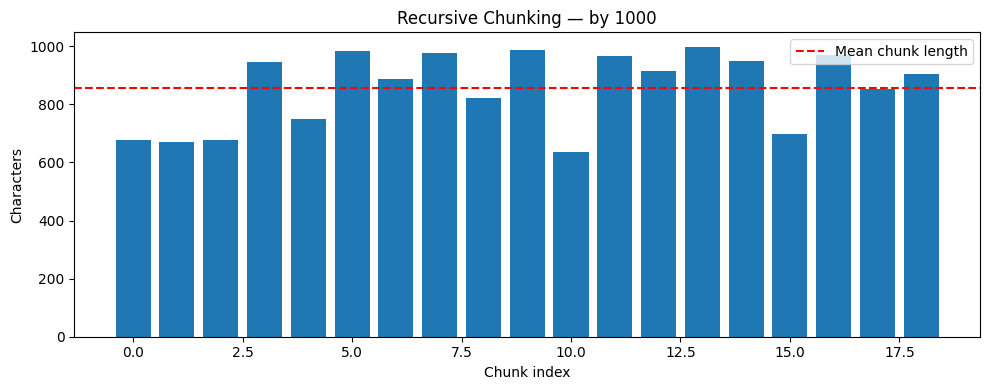

[678, 672, 677, 946, 750, 984, 887, 976, 822, 987, 637, 965, 916, 998, 948, 697, 971, 854, 903]


In [48]:
import matplotlib.pyplot as plt
import statistics

lengths = [c["char_length"] for c in chunked["chunks"]]
mean_len = statistics.mean(lengths)

plt.figure(figsize=(10, 4))
plt.bar(range(len(lengths)), lengths)
plt.xlabel("Chunk index")
plt.ylabel("Characters")
plt.title("Recursive Chunking — by 1000")
plt.axhline(y=mean_len, color="red", linestyle="--", label="Mean chunk length")
plt.legend()
plt.tight_layout()
plt.show()

print(lengths)

# Semantic Chunking 2

In [35]:
chunks = chunker.create_documents([doc["text"]])
print(f"Got {len(chunks)} chunks")

Got 13 chunks


In [36]:
output_dir = PROJECT_ROOT / "outputs" / "test_chunks" / "semantic_p95"
output_dir.mkdir(parents=True, exist_ok=True)

chunked = {
    "filename": doc["filename"],
    "title": doc.get("title"),
    "authors": doc.get("authors"),
    "year": doc.get("year"),
    "strategy": "semantic",
    "breakpoint_type": "percentile",
    "breakpoint_threshold": 95,
    "num_chunks": len(chunks),
    "chunks": [
        {"chunk_id": i, "text": c.page_content, "char_length": len(c.page_content)}
        for i, c in enumerate(chunks)
    ]
}

with open(output_dir / f"{Path(doc['filename']).stem}.json", "w", encoding="utf-8") as f:
    json.dump(chunked, f, ensure_ascii=False, indent=2)

In [37]:
print(json.dumps(chunked, indent=2, ensure_ascii=False)[:10000])

{
  "filename": "algae-1998-13-1-1.pdf",
  "title": "Marine Flora of Oeyondo Islands on the Yellow Sea of Korea",
  "authors": [
    "Tae Oh Cho",
    "Sung Min Boo"
  ],
  "year": "1998",
  "strategy": "semantic",
  "breakpoint_type": "percentile",
  "breakpoint_threshold": 95,
  "num_chunks": 13,
  "chunks": [
    {
      "chunk_id": 0,
      "text": "Algae (The Korean Journal of Phycology) Volume 13(1): 1-11, 1998\n\nMarine Flora of Oeyondo Islands on the Yellow Sea, Korea: I. Green Algae and Seagrasses\n\nTae Oh Cho and Sung Min Boo*\n\nDepartment of Biology, Chungnam National University, Daejon 305-764, Korea\n\nA marine floral survey of benthic green algae and seagrasses was carried out in Oeyondo Islands on the Yellow Sea of Korea from 1992 to 1994. A list of nine genera and eighteen species was compiled: 13 green algae and 5 sea- grasses. Detailed illustrations as well as the keys and short descriptions were given for most of the taxa. Key Words: green algae, marine flora, Oeyo

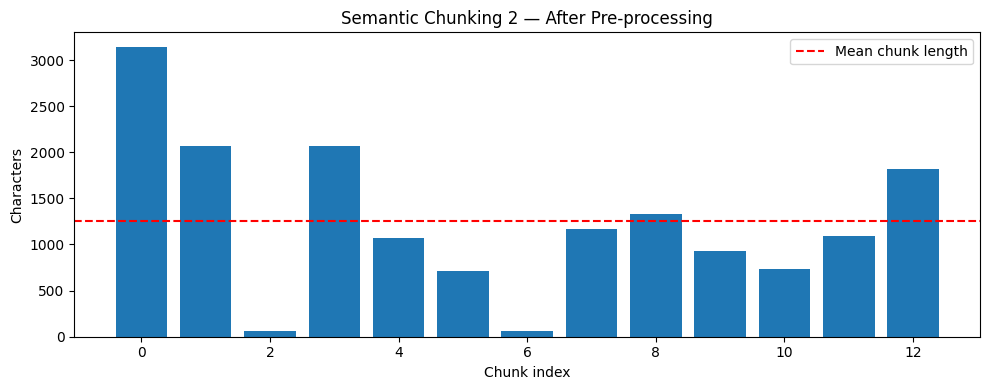

[3143, 2069, 60, 2071, 1069, 713, 61, 1164, 1329, 930, 735, 1091, 1814]


In [42]:
import matplotlib.pyplot as plt
import statistics

lengths = [c["char_length"] for c in chunked["chunks"]]
mean_len = statistics.mean(lengths)

plt.figure(figsize=(10, 4))
plt.bar(range(len(lengths)), lengths)
plt.xlabel("Chunk index")
plt.ylabel("Characters")
plt.title("Semantic Chunking 2 — After Pre-processing")
plt.axhline(y=mean_len, color="red", linestyle="--", label="Mean chunk length")
plt.legend()
plt.tight_layout()
plt.show()

print(lengths)

## Recursive Semantic Chunking
The RSC thresholds from the Latif et al. paper are: Tmax=15,000 (max segment length before initial splitting), Tchunk=1,500 (recursive chunking threshold), Tmerge=350 (minimum chunk size — merge below this), Tfinal=2,500 (hard max; force split above this). The reduction factor δ is 3, applied to the breakpoint threshold each recursive iteration.

### Algorithm explanation
Imagine you have a paper about Baltic seaweed species that's 12,000 characters after preprocessing. That's under Tmax (15,000), so stage 1 does nothing — the whole text goes forward as one segment.
Stage 2 runs the semantic chunker on it. Say it produces 5 chunks: [8000 chars, 3000 chars, 200 chars, 1200 chars, 600 chars]. This is a classic semantic chunking problem: wildly uneven sizes.

Stage 3a walks through each chunk and asks "is this over Tchunk (1,500)?" The 8000-char chunk is way over, so it gets fed back into the semantic chunker, but this time with the breakpoint threshold lowered by δ=3 (so 92 instead of 95). That means it splits at less extreme similarity drops, producing more cuts. Say it produces 4 sub-chunks: [3500, 2000, 1500, 1000]. The 3500 is still over Tchunk, so it goes through again with threshold 89. This keeps recursing until everything is under 1500 or the threshold bottoms out. The 3000-char chunk from the original split also gets re-chunked. The 1200 and 600 are fine, left alone.

Stage 3b now looks at the 200-char chunk. It's under Tmerge (350), so it computes embedding similarity with its left neighbor and right neighbor, and merges with whichever is more similar. So it gets absorbed into a related chunk rather than floating alone.

Stage 4 checks everything one last time. If any chunk somehow ended up over Tfinal (2,500) — maybe the merge step created something big — it gets force-split with the recursive character splitter. This is just a safety net.

The result is chunks that are semantically coherent (because splitting always uses semantic similarity) AND reasonably sized (because of the recursive refinement and merge guardrails). That's the key insight: plain semantic chunking optimizes for coherence but ignores size, recursive character splitting optimizes for size but ignores coherence, and RSC does both.

In [62]:
Tmax = 15000 #max length of document
Tchunk = 1500 #recursive chunking threshold
Tmerge = 350
Tfinal = 2500
reduction = 3
len(text)

23129

In [63]:
def segment_text(text, t_max=15000):
    if len(text) <= t_max:
        return [text]
    
    mid = len(text) // 2
    #nearest comma
    split_point = text.rfind('. ', 0, mid) + 2
    if split_point < 2:
        split_point = mid
    left_segments = segment_text(text[:mid], t_max)
    right_segments = segment_text(text[mid:], t_max)
    
    return left_segments + right_segments

In [65]:
segments = segment_text([doc["text"]])

def recursive_chunk(segments, t_chunk=1500, d=3):
    # Initial semantic chunking
    chunks = []
    for segment in segments:
        chunks.extend(chunker.create_documents([segment]))
    
    # Refining oversized chunks
    refined = []
    for chunk in chunks:
        if len(chunk.page_content) > t_chunk:
            # Re-chunk with progressively lower thresholds
            sub_chunks = refine_chunk(chunk.page_content, t_chunk, 95 - d, d)
            refined.extend(sub_chunks)
        else:
            refined.append(chunk)
    
    return refined


def refine_chunk(text, t_chunk, threshold, d):
    # Base case: small enough or threshold bottomed out
    if len(text) <= t_chunk or threshold <= 0:
        return [text]
    
    # Re-chunk with lower threshold
    chunker.breakpoint_threshold_amount = threshold
    sub_chunks = chunker.create_documents([text])
    
    # Check each sub-chunk, recurse if still too big
    results = []
    for sc in sub_chunks:
        results.extend(refine_chunk(sc.page_content, t_chunk, threshold - d, d))
    
    return results

In [66]:
def merge_small_chunks(refined, embedding_model, t_merge=350):
    merged = list(refined)  # works on a copy
    
    i = 0
    while i < len(merged):
        if len(merged[i]) < t_merge:
            # Compute similarity with neighbors
            chunk_embedding = embedding_model.embed_query(merged[i])
            
            sim_prev = -1
            sim_next = -1
            
            if i > 0:
                prev_embedding = embedding_model.embed_query(merged[i - 1])
                sim_prev = sum(a * b for a, b in zip(chunk_embedding, prev_embedding))#semantic sinilarity between neighbors
            
            if i < len(merged) - 1:
                next_embedding = embedding_model.embed_query(merged[i + 1])
                sim_next = sum(a * b for a, b in zip(chunk_embedding, next_embedding))
            
            # Merge with more similar neighbor
            if sim_prev >= sim_next and i > 0:
                merged[i - 1] = merged[i - 1] + "\n\n" + merged[i]
                merged.pop(i)
            elif i < len(merged) - 1:
                merged[i + 1] = merged[i] + "\n\n" + merged[i + 1]
                merged.pop(i)
            else:
                i += 1  # no neighbors, skip
        else:
            i += 1
    
    return merged

In [67]:
def enforce_max_size(chunks, t_final=2500):
    final = []
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=t_final,
        chunk_overlap=0,
    )
    for chunk in chunks:
        if len(chunk) > t_final:
            sub_chunks = splitter.create_documents([chunk])
            final.extend([sc.page_content for sc in sub_chunks])
        else:
            final.append(chunk)
    
    return final

In [68]:
def rsc_chunk(text: str, embedding_model) -> list[str]:
    # Stage 1: segment if too long
    segments = segment_text(text, t_max=15000)
    
    # Stage 2: initial semantic chunking
    chunker = SemanticChunker(
        embeddings=embedding_model,
        breakpoint_threshold_type="percentile",
        breakpoint_threshold_amount=95,
    )
    chunks = []
    for segment in segments:
        chunks.extend(chunker.create_documents([segment]))
    
    # Stage 3a: recursively split large chunks
    refined = []
    for chunk in chunks:
        if len(chunk.page_content) > 1500:
            refined.extend(refine_chunk(chunk.page_content, 1500, 92, 3))
        else:
            refined.append(chunk.page_content)
    chunks = refined
    
    # Stage 3b: merge small chunks
    chunks = merge_small_chunks(chunks, embedding_model, t_merge=350)
    
    # Stage 4: force split anything still too big
    chunks = enforce_max_size(chunks, t_final=2500)
    
    return chunks

In [69]:
#Function call
rsc_chunks = rsc_chunk(doc["text"], embedding_model)
print(f"Got {len(rsc_chunks)} chunks")

# Save
output_dir = PROJECT_ROOT / "outputs" / "test_chunks" / "rsc"
output_dir.mkdir(parents=True, exist_ok=True)

chunked = {
    "filename": doc["filename"],
    "title": doc.get("title"),
    "authors": doc.get("authors"),
    "year": doc.get("year"),
    "strategy": "rsc",
    "t_chunk": 1500,
    "t_merge": 350,
    "t_final": 2500,
    "delta": 3,
    "num_chunks": len(rsc_chunks),
    "chunks": [
        {"chunk_id": i, "text": c, "char_length": len(c)}
        for i, c in enumerate(rsc_chunks)
    ]
}

with open(output_dir / f"{Path(doc['filename']).stem}.json", "w", encoding="utf-8") as f:
    json.dump(chunked, f, ensure_ascii=False, indent=2)

Got 20 chunks


In [ ]:
#Display to read
with open(output_dir / "algae-1998-13-1-1.json", "r", encoding="utf-8") as f:
    rsc_result = json.load(f)

for c in rsc_result["chunks"]:
    print(f"--- Chunk {c['chunk_id']} ({c['char_length']} chars) ---")
    print(c["text"][:200])
    print()

--- Chunk 0 (1546 chars) ---
Algae (The Korean Journal of Phycology) Volume 13(1): 1-11, 1998

Marine Flora of Oeyondo Islands on the Yellow Sea, Korea: I. Green Algae and Seagrasses

Tae Oh Cho and Sung Min Boo*

Department of B

--- Chunk 1 (748 chars) ---
The marine algal list of these islands was compiled by Rho (1958), Kang (1966), Lee and Boo (1988), and Cho and Boo (1996). The biogeo- graphic aspects of the Yellow Sea were discussed by Koh and Oh (

--- Chunk 2 (438 chars) ---
Observations and drawings were done under Olympus microscope with drawing apparatus. Sections for anatomical examination were made by hands on a slide glass under a stereomicroscope. The size and dime

--- Chunk 3 (411 chars) ---
(1995). The uncertain species were excluded in the list. All the speci- mens identified in this study have been mounted on herbarium sheets and deposited in the herbarium of Department of Biology, Chu

--- Chunk 4 (463 chars) ---
13(1), 1998

be)

DAECHONGDO

OEYONDO

Kiitzing and

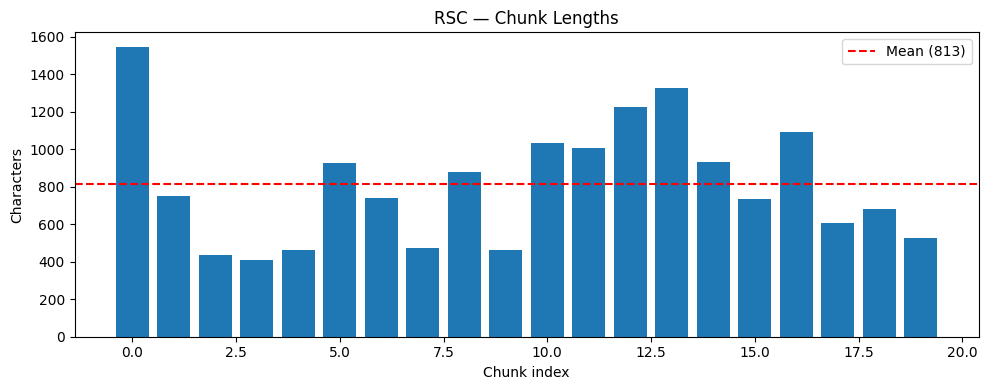

[1546, 748, 438, 411, 463, 924, 742, 473, 877, 465, 1033, 1007, 1226, 1329, 930, 735, 1091, 607, 681, 525]


In [72]:
lengths = [c["char_length"] for c in rsc_result["chunks"]]
mean_len = statistics.mean(lengths)

plt.figure(figsize=(10, 4))
plt.bar(range(len(lengths)), lengths)
plt.xlabel("Chunk index")
plt.ylabel("Characters")
plt.title("RSC — Chunk Lengths")
plt.axhline(y=mean_len, color="red", linestyle="--", label=f"Mean ({mean_len:.0f})")
plt.legend()
plt.tight_layout()
plt.show()
print(lengths)